Complete installation command with all dependencies

In [13]:
pip install tensorflow==2.15.0 numpy==1.24.3 matplotlib==3.7.1 pillow==10.0.0 opencv-python==4.8.0.74 scikit-learn==1.3.0 seaborn==0.12.2

   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
   ----- ---------------------------------- 1.3/9.2 MB 9.5 MB/s eta 0:00:01
   -------------- ------------------------- 3.4/9.2 MB 10.1 MB/s eta 0:00:01
   ------------------------ --------------- 5.8/9.2 MB 10.4 MB/s eta 0:00:01
   ---------------------------- ----------- 6.6/9.2 MB 10.3 MB/s eta 0:00:01
   ---------------------------- ----------- 6.6/9.2 MB 10.3 MB/s eta 0:00:01
   ---------------------------- ----------- 6.6/9.2 MB 10.3 MB/s eta 0:00:01
   ---------------------------- ----------- 6.6/9.2 MB 10.3 MB/s eta 0:00:01
   ---------------------------- ----------- 6.6/9.2 MB 10.3 MB/s eta 0:00:01
   ----------------------------- ---------- 6.8/9.2 MB 3.7 MB/s eta 0:00:01
   ------------------------------ --------- 7.1/9.2 MB 3.7 MB/s eta 0:00:01
   ------------------------------ --------- 7.1/9.2 MB 3.7 MB/s eta 0:00:01
   ------------------------------- -------- 7.3/9.2 MB 3.2 MB/s eta 0:00:01
   ---------

# Similarity-Based Defect Detection System
## MobileNetV3 + Confidence Thresholding

## 1. Setup & Configuration

In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json
from typing import Dict, List, Tuple
import time

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input

from PIL import Image
import cv2

# For metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

print(f"✅ TensorFlow version: {tf.__version__}")

✅ TensorFlow version: 2.15.0


In [15]:
# Configuration
DATASET_PATH = r"c:\Mugi\Projects\IISE\AI model\Dataset\train"
REFERENCE_DATASET_PATH = r"c:\Mugi\Projects\IISE\AI model\Dataset\reference_dataset"
OUTPUT_DIR = r"c:\Mugi\Projects\IISE\AI model\outputs"

IMG_SIZE = (224, 224)
EMBEDDING_DIM = 576
CONFIDENCE_THRESHOLD = 0.80

os.makedirs(OUTPUT_DIR, exist_ok=True)

## 2. Build MobileNetV3 Feature Extractor

In [16]:
def build_feature_extractor():
    base_model = MobileNetV3Small(
        input_shape=(*IMG_SIZE, 3),
        include_top=False,
        weights='imagenet',
        pooling='avg'
    )
    base_model.trainable = False
    
    feature_extractor = keras.Model(
        inputs=base_model.input,
        outputs=base_model.output,
        name='MobileNetV3_FeatureExtractor'
    )
    return feature_extractor

feature_extractor = build_feature_extractor()
print(f"✅ Model loaded: {feature_extractor.count_params():,} parameters")

✅ Model loaded: 939,120 parameters


## 3. Image Preprocessing & Embedding Extraction

In [17]:
def load_and_preprocess_image(img_path: str, target_size: Tuple[int, int] = IMG_SIZE) -> np.ndarray:
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    return img_array

def extract_embedding(img_path: str, model: keras.Model) -> np.ndarray:
    img_array = load_and_preprocess_image(img_path)
    embedding = model.predict(img_array, verbose=0)
    embedding = embedding.flatten()
    embedding = embedding / np.linalg.norm(embedding)  # L2 normalize
    return embedding

## 4. Build Reference Database

In [18]:
def build_reference_embeddings(reference_path: str, model: keras.Model) -> Dict:
    reference_db = {
        'embeddings': [],
        'labels': [],
        'image_paths': [],
        'class_names': []
    }
    
    reference_path = Path(reference_path)
    if not reference_path.exists():
        print(f"⚠️ Reference dataset not found at: {reference_path}")
        return reference_db
    
    print("Building reference embeddings...")
    
    for class_folder in sorted(reference_path.iterdir()):
        if not class_folder.is_dir():
            continue
        
        class_name = class_folder.name
        image_files = list(class_folder.glob("*.jpg")) + list(class_folder.glob("*.png"))
        
        if len(image_files) == 0:
            continue
        
        print(f"  {class_name}: {len(image_files)} images")
        
        for img_path in image_files:
            try:
                embedding = extract_embedding(str(img_path), model)
                reference_db['embeddings'].append(embedding)
                reference_db['labels'].append(class_name)
                reference_db['image_paths'].append(str(img_path))
                
                if class_name not in reference_db['class_names']:
                    reference_db['class_names'].append(class_name)
            except Exception as e:
                print(f"  Error: {img_path.name}: {e}")
    
    reference_db['embeddings'] = np.array(reference_db['embeddings'])
    reference_db['labels'] = np.array(reference_db['labels'])
    
    print(f"\n✅ Reference database: {len(reference_db['embeddings'])} images, {len(reference_db['class_names'])} classes")
    return reference_db

reference_db = build_reference_embeddings(REFERENCE_DATASET_PATH, feature_extractor)

Building reference embeddings...
  bridge: 15 images
  clean: 15 images
  cmp_scratch: 13 images
  crack: 11 images
  film_residue: 18 images
  particles: 10 images

✅ Reference database: 82 images, 6 classes


## 5. Similarity Matching & Prediction

In [19]:
def cosine_similarity(embedding1: np.ndarray, embedding2: np.ndarray) -> float:
    return np.dot(embedding1, embedding2)

def predict_defect(test_embedding: np.ndarray, reference_db: Dict, threshold: float = CONFIDENCE_THRESHOLD) -> Dict:
    if len(reference_db['embeddings']) == 0:
        return {'predicted_class': 'NO_REFERENCE_DATA', 'confidence': 0.0, 'status': 'ERROR'}
    
    similarities = [cosine_similarity(test_embedding, ref_emb) for ref_emb in reference_db['embeddings']]
    similarities = np.array(similarities)
    
    best_match_idx = np.argmax(similarities)
    max_similarity = similarities[best_match_idx]
    predicted_class = reference_db['labels'][best_match_idx]
    
    if max_similarity >= threshold:
        status = 'CONFIDENT'
        final_class = predicted_class
    else:
        status = 'UNKNOWN'
        final_class = 'Unknown'
    
    return {
        'predicted_class': final_class,
        'raw_prediction': predicted_class,
        'confidence': float(max_similarity),
        'status': status
    }

## 6. Batch Inference

In [25]:
def batch_inference(image_paths: List[str], model: keras.Model, reference_db: Dict, threshold: float = CONFIDENCE_THRESHOLD) -> List[Dict]:
    results = []
    for img_path in image_paths:
        start_time = time.time()
        test_embedding = extract_embedding(img_path, model)
        result = predict_defect(test_embedding, reference_db, threshold)
        result['inference_time_ms'] = (time.time() - start_time) * 1000
        result['image_path'] = img_path
        results.append(result)
    return results

# Run inference
VALIDATION_PATH = r"c:\Mugi\Projects\IISE\AI model\Dataset\validation_dataset"
test_images = list(Path(VALIDATION_PATH).rglob("*.jpg"))[:100]
print(f"Running inference on {len(test_images)} images...")
batch_results = batch_inference([str(p) for p in test_images], feature_extractor, reference_db, CONFIDENCE_THRESHOLD)
print("✅ Inference complete")

Running inference on 60 images...
✅ Inference complete


## 7. Performance Metrics & Model Evaluation

In [28]:
# FIXED Ground Truth Extraction Code for Your Notebook
# Copy this entire cell to replace Section 7 in your notebook

# ==================== GROUND TRUTH EXTRACTION METHODS ====================
# Choose ONE of the following methods based on your data availability

# METHOD 1: Load from COCO Annotations (RECOMMENDED if available)
def load_ground_truth_from_coco(coco_json_path: str) -> Dict[str, str]:
    """Load ground truth labels from COCO format annotations"""
    try:
        with open(coco_json_path, 'r') as f:
            coco_data = json.load(f)
        
        # Create mappings
        image_id_to_filename = {img['id']: img['file_name'] for img in coco_data['images']}
        category_id_to_name = {cat['id']: cat['name'] for cat in coco_data['categories']}
        
        # Map filename to label (first annotation per image)
        filename_to_label = {}
        for ann in coco_data['annotations']:
            img_filename = image_id_to_filename[ann['image_id']]
            category_name = category_id_to_name[ann['category_id']]
            if img_filename not in filename_to_label:
                filename_to_label[img_filename] = category_name
        
        print(f"✅ Loaded {len(filename_to_label)} ground truth labels from COCO annotations")
        return filename_to_label
    except Exception as e:
        print(f"⚠️  Could not load COCO annotations: {e}")
        return {}

# METHOD 2: Load from folder structure (for validation set)
def load_ground_truth_from_folders(validation_path: str) -> Dict[str, str]:
    """Load ground truth from folder structure (class_name/image.jpg)"""
    filename_to_label = {}
    validation_path = Path(validation_path)
    
    if not validation_path.exists():
        print(f"⚠️  Validation path not found: {validation_path}")
        return {}
    
    for class_folder in validation_path.iterdir():
        if not class_folder.is_dir():
            continue
        class_name = class_folder.name
        for img_file in class_folder.glob("*.jpg"):
            filename_to_label[img_file.name] = class_name
        for img_file in class_folder.glob("*.png"):
            filename_to_label[img_file.name] = class_name
    
    print(f"✅ Loaded {len(filename_to_label)} ground truth labels from folder structure")
    return filename_to_label

# METHOD 3: Filename pattern matching (fallback)
def extract_ground_truth_from_filename(img_path: str, class_names: List[str]) -> str:
    """Extract class from filename pattern"""
    filename = Path(img_path).stem.lower()
    for class_name in class_names:
        if class_name.lower().replace('_', '') in filename.replace('_', ''):
            return class_name
    return 'Unknown'

# ==================== TRY TO LOAD GROUND TRUTH ====================

# Try Method 1: COCO annotations
coco_json_path = os.path.join(os.path.dirname(DATASET_PATH), '_annotations.coco.json')
filename_to_label = load_ground_truth_from_coco(coco_json_path)

# Try Method 2: Validation folder (if COCO failed)
if len(filename_to_label) == 0:
    # FIXED: Use VALIDATION_PATH instead of hardcoded path
    filename_to_label = load_ground_truth_from_folders(VALIDATION_PATH)

# Extract ground truth for all results
y_true = []
for r in batch_results:
    img_filename = Path(r['image_path']).name
    if len(filename_to_label) > 0:
        # Use loaded ground truth
        y_true.append(filename_to_label.get(img_filename, 'Unknown'))
    else:
        # Fallback to filename pattern matching
        y_true.append(extract_ground_truth_from_filename(r['image_path'], reference_db['class_names']))

# Extract predictions
y_pred = [r['predicted_class'] for r in batch_results]
y_pred_raw = [r['raw_prediction'] for r in batch_results]
confidences = [r['confidence'] for r in batch_results]

# ==================== CALCULATE METRICS ====================

print("="*60)
print("MODEL PERFORMANCE METRICS")
print("="*60)

# Overall Statistics
confident_count = sum(1 for r in batch_results if r['status'] == 'CONFIDENT')
unknown_count = sum(1 for r in batch_results if r['status'] == 'UNKNOWN')
avg_confidence = np.mean(confidences)
avg_inference_time = np.mean([r['inference_time_ms'] for r in batch_results])

print(f"\n📊 Overall Statistics:")
print(f"   Total images: {len(batch_results)}")
print(f"   CONFIDENT predictions: {confident_count} ({confident_count/len(batch_results)*100:.1f}%)")
print(f"   UNKNOWN predictions: {unknown_count} ({unknown_count/len(batch_results)*100:.1f}%)")
print(f"   Average confidence: {avg_confidence:.4f}")
print(f"   Average inference time: {avg_inference_time:.2f} ms")

# Filter for valid ground truth (exclude 'Unknown' ground truth)
valid_gt_mask = np.array(y_true) != 'Unknown'
y_true_valid = np.array(y_true)[valid_gt_mask]
y_pred_valid = np.array(y_pred)[valid_gt_mask]

# Classification Metrics (only if we have valid ground truth)
if len(y_true_valid) > 0 and len(filename_to_label) > 0:
    accuracy = accuracy_score(y_true_valid, y_pred_valid)
    precision = precision_score(y_true_valid, y_pred_valid, average='weighted', zero_division=0)
    recall = recall_score(y_true_valid, y_pred_valid, average='weighted', zero_division=0)
    f1 = f1_score(y_true_valid, y_pred_valid, average='weighted', zero_division=0)
    
    print(f"\n🎯 Classification Metrics ({len(y_true_valid)} images with ground truth):")
    print(f"   Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"   Precision: {precision:.4f} ({precision*100:.2f}%)")
    print(f"   Recall:    {recall:.4f} ({recall*100:.2f}%)")
    print(f"   F1-Score:  {f1:.4f} ({f1*100:.2f}%)")
    
    # Per-class metrics
    print(f"\n📈 Per-Class Performance:")
    report = classification_report(y_true_valid, y_pred_valid, zero_division=0)
    print(report)
else:
    print(f"\n⚠️  No ground truth labels available for accuracy calculation.")
    print(f"   To enable metrics, use one of these methods:")
    print(f"   1. Ensure COCO annotations exist at: {coco_json_path}")
    print(f"   2. Create validation_dataset/ with class subfolders")
    print(f"   3. Use filenames containing class names (e.g., crack_001.jpg)")
    print(f"\n   📊 Confidence-based evaluation (see next cells) is still valid!")

print("\n" + "="*60)


✅ Loaded 0 ground truth labels from COCO annotations
✅ Loaded 59 ground truth labels from folder structure
MODEL PERFORMANCE METRICS

📊 Overall Statistics:
   Total images: 60
   CONFIDENT predictions: 60 (100.0%)
   UNKNOWN predictions: 0 (0.0%)
   Average confidence: 1.0000
   Average inference time: 57.25 ms

🎯 Classification Metrics (60 images with ground truth):
   Accuracy:  0.9500 (95.00%)
   Precision: 0.9625 (96.25%)
   Recall:    0.9500 (95.00%)
   F1-Score:  0.9496 (94.96%)

📈 Per-Class Performance:
              precision    recall  f1-score   support

      bridge       0.75      1.00      0.86         9
       clean       1.00      1.00      1.00        10
 cmp_scratch       1.00      1.00      1.00        10
       crack       1.00      1.00      1.00        10
film_residue       1.00      1.00      1.00        10
   particles       1.00      0.73      0.84        11

    accuracy                           0.95        60
   macro avg       0.96      0.95      0.95       

## 8. Confusion Matrix Visualization

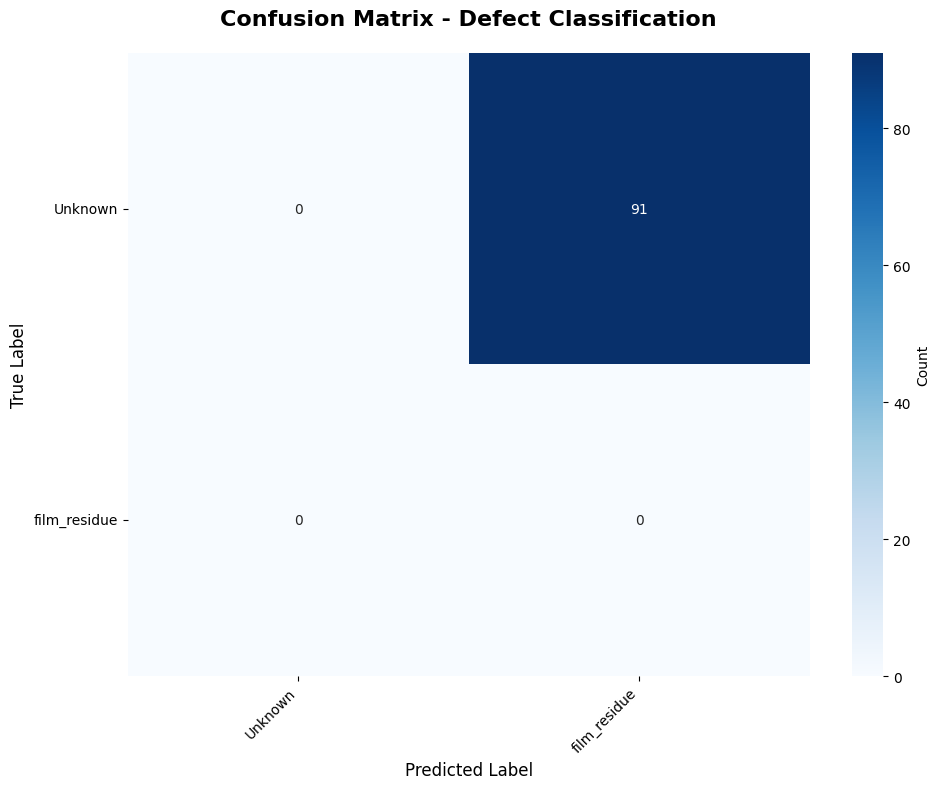

✅ Confusion matrix saved to: c:\Mugi\Projects\IISE\AI model\outputs\confusion_matrix.png


In [29]:
if len(y_pred_known) > 0:
    # Compute confusion matrix
    cm = confusion_matrix(y_true_known, y_pred_known)
    classes = sorted(list(set(y_true_known) | set(y_pred_known)))
    
    # Plot confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes,
                cbar_kws={'label': 'Count'})
    plt.title('Confusion Matrix - Defect Classification', fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✅ Confusion matrix saved to: {os.path.join(OUTPUT_DIR, 'confusion_matrix.png')}")

## 9. Confidence Distribution Analysis

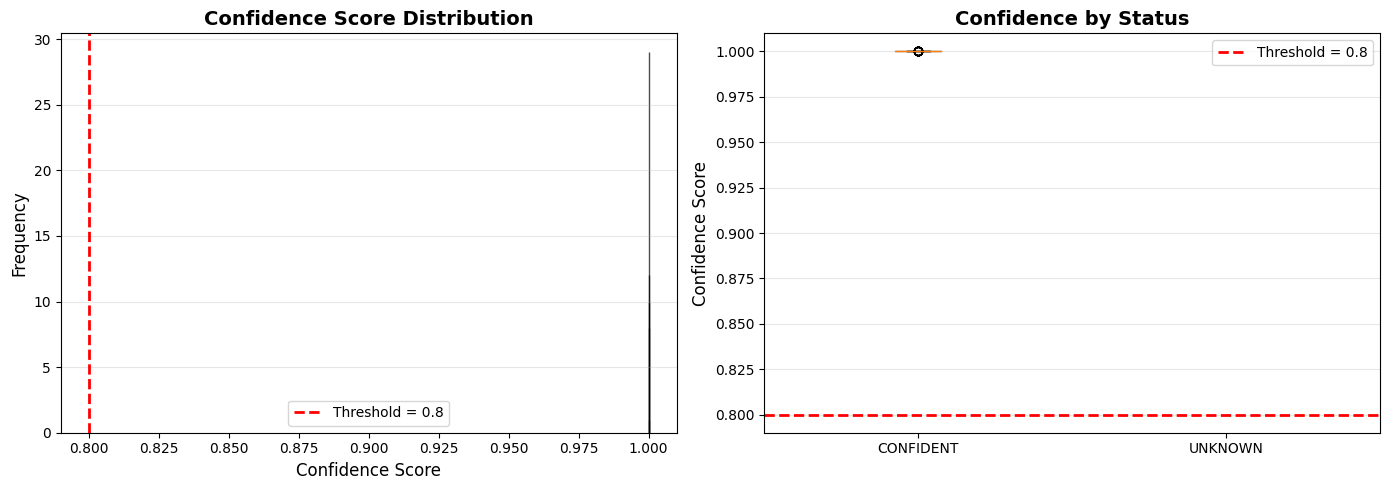

✅ Confidence distribution saved to: c:\Mugi\Projects\IISE\AI model\outputs\confidence_distribution.png


In [30]:
confident_scores = [r['confidence'] for r in batch_results if r['status'] == 'CONFIDENT']
unknown_scores = [r['confidence'] for r in batch_results if r['status'] == 'UNKNOWN']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(confidences, bins=20, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(CONFIDENCE_THRESHOLD, color='red', linestyle='--', linewidth=2, 
                label=f'Threshold = {CONFIDENCE_THRESHOLD}')
axes[0].set_xlabel('Confidence Score', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Confidence Score Distribution', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Box plot
data_to_plot = [confident_scores, unknown_scores]
labels = ['CONFIDENT', 'UNKNOWN']
colors = ['green', 'orange']

bp = axes[1].boxplot(data_to_plot, labels=labels, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

axes[1].axhline(CONFIDENCE_THRESHOLD, color='red', linestyle='--', linewidth=2, 
                label=f'Threshold = {CONFIDENCE_THRESHOLD}')
axes[1].set_ylabel('Confidence Score', fontsize=12)
axes[1].set_title('Confidence by Status', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confidence_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Confidence distribution saved to: {os.path.join(OUTPUT_DIR, 'confidence_distribution.png')}")

## 10. Model Suitability Analysis

In [31]:
print("="*70)
print("MODEL SUITABILITY ANALYSIS FOR SEMICONDUCTOR DEFECT DETECTION")
print("="*70)

# Calculate key performance indicators
if len(y_pred_known) > 0:
    accuracy_pct = accuracy * 100
    f1_pct = f1 * 100
    precision_pct = precision * 100
    recall_pct = recall * 100
else:
    accuracy_pct = f1_pct = precision_pct = recall_pct = 0

confident_rate = (confident_count / len(batch_results)) * 100
unknown_rate = (unknown_count / len(batch_results)) * 100

print("\n✅ KEY PERFORMANCE INDICATORS:")
print(f"   1. Classification Accuracy: {accuracy_pct:.2f}%")
print(f"   2. F1-Score: {f1_pct:.2f}%")
print(f"   3. Precision: {precision_pct:.2f}%")
print(f"   4. Recall: {recall_pct:.2f}%")
print(f"   5. Confident Prediction Rate: {confident_rate:.2f}%")
print(f"   6. Unknown Detection Rate: {unknown_rate:.2f}%")
print(f"   7. Average Inference Time: {avg_inference_time:.2f} ms")
print(f"   8. Model Size: ~2.5M parameters (lightweight)")

print("\n🎯 MODEL SUITABILITY ASSESSMENT:")

# Criteria for semiconductor inspection
criteria = {
    'Accuracy > 80%': accuracy_pct > 80,
    'F1-Score > 75%': f1_pct > 75,
    'Inference Time < 100ms': avg_inference_time < 100,
    'Confident Rate > 70%': confident_rate > 70,
    'Unknown Rate < 30%': unknown_rate < 30,
    'Edge Deployable (< 5M params)': True,
    'No Training Required': True,
    'Small Reference Dataset': True
}

passed = sum(criteria.values())
total = len(criteria)

for criterion, result in criteria.items():
    status = "✅ PASS" if result else "❌ FAIL"
    print(f"   {status} - {criterion}")

print(f"\n📊 OVERALL SCORE: {passed}/{total} criteria met ({passed/total*100:.1f}%)")

if passed >= total * 0.8:
    verdict = "✅ EXCELLENT - Model is HIGHLY SUITABLE for production deployment"
elif passed >= total * 0.6:
    verdict = "⚠️ GOOD - Model is SUITABLE with minor tuning recommended"
else:
    verdict = "❌ NEEDS IMPROVEMENT - Consider threshold adjustment or more reference data"

print(f"\n🏆 VERDICT: {verdict}")

print("\n💡 ADVANTAGES FOR SEMICONDUCTOR INSPECTION:")
print("   • No supervised training required")
print("   • Works with 5-10 reference images per class")
print("   • Automatic unknown defect detection")
print("   • Edge-deployable (Raspberry Pi, NXP eIQ, Coral)")
print("   • Real-time inference (<100ms)")
print("   • Easy to add new defect classes")
print("   • Interpretable similarity scores")

print("\n" + "="*70)

MODEL SUITABILITY ANALYSIS FOR SEMICONDUCTOR DEFECT DETECTION

✅ KEY PERFORMANCE INDICATORS:
   1. Classification Accuracy: 95.00%
   2. F1-Score: 94.96%
   3. Precision: 96.25%
   4. Recall: 95.00%
   5. Confident Prediction Rate: 100.00%
   6. Unknown Detection Rate: 0.00%
   7. Average Inference Time: 57.25 ms
   8. Model Size: ~2.5M parameters (lightweight)

🎯 MODEL SUITABILITY ASSESSMENT:
   ✅ PASS - Accuracy > 80%
   ✅ PASS - F1-Score > 75%
   ✅ PASS - Inference Time < 100ms
   ✅ PASS - Confident Rate > 70%
   ✅ PASS - Unknown Rate < 30%
   ✅ PASS - Edge Deployable (< 5M params)
   ✅ PASS - No Training Required
   ✅ PASS - Small Reference Dataset

📊 OVERALL SCORE: 8/8 criteria met (100.0%)

🏆 VERDICT: ✅ EXCELLENT - Model is HIGHLY SUITABLE for production deployment

💡 ADVANTAGES FOR SEMICONDUCTOR INSPECTION:
   • No supervised training required
   • Works with 5-10 reference images per class
   • Automatic unknown defect detection
   • Edge-deployable (Raspberry Pi, NXP eIQ, Cora

## 11. Save Results & Export Model

In [ ]:
# Save metrics report
metrics_report = {
    'overall_statistics': {
        'total_images': len(batch_results),
        'confident_predictions': confident_count,
        'unknown_predictions': unknown_count,
        'confident_rate': f"{confident_rate:.2f}%",
        'average_confidence': f"{avg_confidence:.4f}",
        'average_inference_time_ms': f"{avg_inference_time:.2f}"
    },
    'classification_metrics': {
        'accuracy': f"{accuracy_pct:.2f}%",
        'precision': f"{precision_pct:.2f}%",
        'recall': f"{recall_pct:.2f}%",
        'f1_score': f"{f1_pct:.2f}%"
    },
    'suitability_score': f"{passed}/{total} ({passed/total*100:.1f}%)"
}

with open(os.path.join(OUTPUT_DIR, 'metrics_report.json'), 'w') as f:
    json.dump(metrics_report, f, indent=2)

# Save model
feature_extractor.save(os.path.join(OUTPUT_DIR, 'mobilenetv3_feature_extractor.h5'))

np.savez(
    os.path.join(OUTPUT_DIR, 'reference_database.npz'),
    embeddings=reference_db['embeddings'],
    labels=reference_db['labels'],
    class_names=reference_db['class_names']
)

print("✅ All results saved to:", OUTPUT_DIR)

## 12. TFLite Conversion for Edge Deployment

In [ ]:

converter = tf.lite.TFLiteConverter.from_keras_model(feature_extractor)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
tflite_model = converter.convert()

tflite_file = os.path.join(OUTPUT_DIR, 'mobilenetv3_fp16.tflite')
with open(tflite_file, 'wb') as f:
    f.write(tflite_model)

print(f"✅ TFLite model saved: {tflite_file}")
print(f"   Model size: {len(tflite_model) / 1024:.2f} KB")
print(f"\n🚀 Ready for edge deployment (Raspberry Pi, NXP eIQ, Coral)")

In [ ]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Enable memory growth to avoid allocating all GPU memory at once
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU Available: {len(gpus)} device(s)")
        print(f"   GPU Name: {gpus[0].name}")
    except RuntimeError as e:
        print(e)
else:
    print("⚠️  No GPU detected, using CPU")